In [7]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training.npy')
y_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training_labels.npy')
X_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test.npy')
y_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test_labels.npy')

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

embedding = Embedding(input_dim=300 + 1,  # vocab size, including the 0-th word used for padding
                      output_dim=int(3e2),
                      trainable=True)

model = Sequential()
model.add(embedding)
# model.add(Conv1D(128, 7, input_shape=(X_train.shape[1],1)))
# model.add(Dropout(0.25))
# model.add(Conv1D(128, 5))
# model.add(Dropout(0.25))
model.add(Conv1D(128, 3, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.25))
model.add(Bidirectional(LSTM(128, return_sequences=True,)))#
model.add(Dropout(0.25))
model.add(Bidirectional(LSTM(128)))
# model.add(Dropout(0.25))
# model.add(Dense(32))
# model.add(Dropout(0.25))
# model.add(Dense(128))
model.add(Dropout(0.25))
model.add(Dense(128))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()
callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, None, 300)         90300     
                                                                 
 conv1d_2 (Conv1D)           (None, None, 128)         115328    
                                                                 
 dropout_6 (Dropout)         (None, None, 128)         0         
                                                                 
 bidirectional_4 (Bidirecti  (None, None, 256)         263168    
 onal)                                                           
                                                                 
 dropout_7 (Dropout)         (None, None, 256)         0         
                                                                 
 bidirectional_5 (Bidirecti  (None, 256)               394240    
 onal)                                                

In [9]:
history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1)


Epoch 1/100
22/22 [==============================] - 23s 706ms/step - loss: 0.6909 - accuracy: 0.5552 - val_loss: 0.7320 - val_accuracy: 0.0016
Epoch 2/100
22/22 [==============================] - 14s 638ms/step - loss: 0.6883 - accuracy: 0.5553 - val_loss: 0.7648 - val_accuracy: 0.0000e+00
Epoch 3/100
22/22 [==============================] - 14s 638ms/step - loss: 0.6867 - accuracy: 0.5556 - val_loss: 0.7928 - val_accuracy: 0.0000e+00
Epoch 4/100
22/22 [==============================] - 14s 655ms/step - loss: 0.6862 - accuracy: 0.5556 - val_loss: 0.8106 - val_accuracy: 0.0000e+00
Epoch 5/100
22/22 [==============================] - 14s 659ms/step - loss: 0.6860 - accuracy: 0.5556 - val_loss: 0.8109 - val_accuracy: 0.0000e+00
Epoch 6/100
22/22 [==============================] - 15s 662ms/step - loss: 0.6857 - accuracy: 0.5556 - val_loss: 0.8103 - val_accuracy: 0.0000e+00
Epoch 7/100
22/22 [==============================] - 15s 674ms/step - loss: 0.6854 - accuracy: 0.5556 - val_loss: 0.

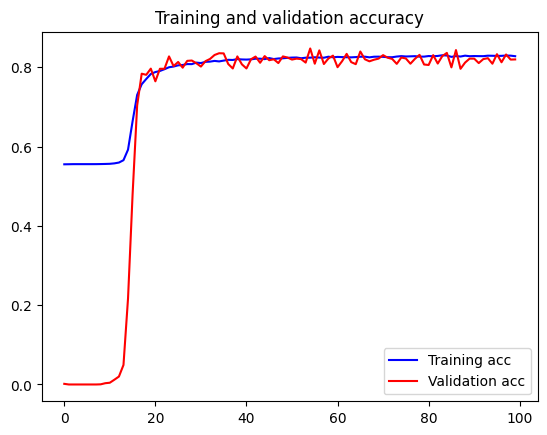

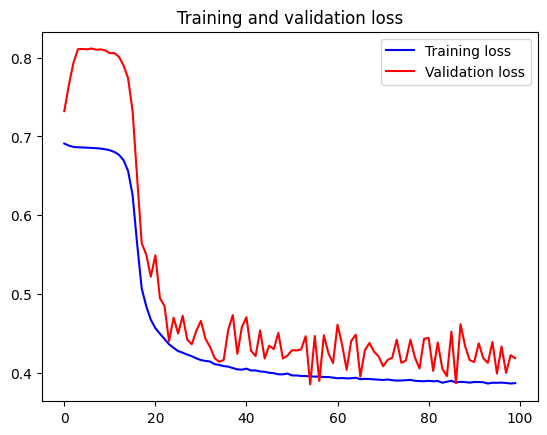

In [10]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [11]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 5s 207ms/step - loss: 0.3861 - accuracy: 0.8255

ACCURACY: 0.8255130052566528
LOSS: 0.3861122131347656
